Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#from tensorflow.keras.utils import to_categorical

In [ ]:
additional_test = pd.read_csv('test/Features/additional_features.csv')
color_test = pd.read_csv('test/Features/color_histogram.csv')
hog_test = pd.read_csv('test/Features/hog_pca.csv')
testing = pd.read_csv('test/test_metadata.csv')

additional_train = pd.read_csv('train/Features/additional_features.csv')
color_train = pd.read_csv('train/Features/color_histogram.csv')
hog_train = pd.read_csv('train/Features/hog_pca.csv')
training = pd.read_csv('train/train_metadata.csv')


# PREPROCESSING THE DATA
# No need for handling missing values as the training set seems to be complete
# print(combined.isna().sum())

# Standardising additional_features 
additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler = StandardScaler()
additional_train[additional_features_columns] = scaler.fit_transform(additional_train[additional_features_columns])

# Standardising color histograms
color_columns = [col for col in color_train.columns if col.startswith("ch_")]
color_train[color_columns] = scaler.fit_transform(color_train[color_columns])

hog_columns = [col for col in hog_train.columns if col != 'image_path']
hog_train[hog_columns] = scaler.fit_transform(hog_train[hog_columns])

# Once preprocessed, we can now merge the features together for the training metadata set
combined = pd.merge(training, additional_train, on='image_path')
combined = pd.merge(combined, color_train, on='image_path')
combined = pd.merge(combined, hog_train, on='image_path')
combined = combined[[col for col in combined.columns if col != 'ClassId'] + ['ClassId']]

# print number of unique classidis  
print("Number of unique ClassIds in training set:", combined['ClassId'].nunique())


Number of unique ClassIds in training set: 43


In [50]:
# NEURAL NETWORK
X_train = np.array(combined.drop(columns=['id', 'image_path', 'ClassId']))
Y_train = np.array(combined['ClassId'])

X = X_train.T
m, n = X_train.shape

indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)

X_train = X_train[indices]
Y_train = Y_train[indices]


In [51]:
numInputs = X.shape[0]
numHidden = 256
numOutput = 43

# Necessary functions for the neural network
def init_params():
    W1 = np.random.randn(numHidden, numInputs) * np.sqrt(2. / numInputs)
    b1 = np.zeros((numHidden, 1))
    W2 = np.random.randn(numOutput, numHidden) * np.sqrt(2. / numHidden)
    b2 = np.zeros((numOutput, 1))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1  
    A1 = np.maximum(0, Z1) 
    Z2 = np.dot(W2, A1) + b2
    exp_scores = np.exp(Z2 - np.max(Z2, axis=0, keepdims=True))
    A2 = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)
    return A1, A2

def backward_propagation(X, Y, A1, A2, W1, W2):
    m = X.shape[1]
    dZ2 = A2 - Y 
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = np.dot(W2.T, dZ2) * (A1 > 0)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def one_hot_encode(Y, num_classes):
    m = Y.shape[0]
    Y_encoded = np.zeros((num_classes, m))
    Y_encoded[Y, np.arange(m)] = 1
    return Y_encoded

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

def get_accuracy(A2, Y):
    predictions = np.argmax(A2, axis=0)
    accuracy = np.mean(predictions == Y)
    return accuracy*100

def predict(A2):
    return np.argmax(A2, axis=0)

def gradient_descent(X, Y, W1, b1, W2, b2, learning_rate=0.01, epochs=1000):
    Y_encoded = one_hot_encode(Y, numOutput)
    for epoch in range(epochs):
        A1, A2 = forward_propagation(X, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward_propagation(X, Y_encoded, A1, A2, W1, W2)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)
        
        if epoch % 100 == 0:
            log_probs = -np.log(A2[Y, np.arange(Y.shape[0])])
            loss = np.mean(log_probs)
            print(f'Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {get_accuracy(A2, Y):.4f}')
    
    return W1, b1, W2, b2

X = X_train.T 
W1, b1, W2, b2 = gradient_descent(X, Y_train, *init_params(), learning_rate=0.1, epochs=1000)


# Confusion Matrix
A1, A2 = forward_propagation(X, W1, b1, W2, b2)
Y_pred = predict(A2)
conf_matrix = confusion_matrix(Y_train, Y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Y_train, Y_pred))
# numhidden: 512 = 93.0029
# numhidden: 368 = 91.8732
# numhidden: 300 = 90.1786
# numhidden: 256 = 88.9759




Epoch 0, Loss: 4.7350, Accuracy: 2.2959


KeyboardInterrupt: 

Best KNN Model Accuracy on Additional Features: 0.2823 with parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.28      0.34      0.31        62
           2       0.33      0.35      0.34        63
           3       0.32      0.31      0.31        39
           4       0.24      0.27      0.26        55
           5       0.29      0.29      0.29        52
           6       0.56      0.42      0.48        12
           7       0.26      0.28      0.27        40
           8       0.26      0.28      0.27        39
           9       0.22      0.24      0.23        41
          10       0.32      0.41      0.36        56
          11       0.22      0.14      0.17        37
          12       0.31      0.32      0.31        59
          13       0.27      0.35      0.31        60
          14       0.30      0.27      0.29        2

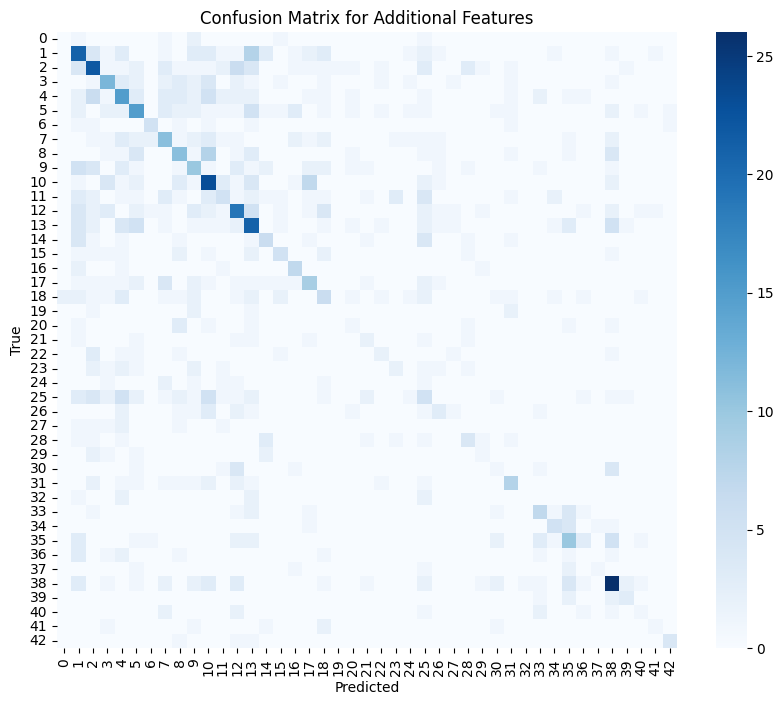

C:\Users\asus\AppData\Local\Temp\ipykernel_3724\1670368156.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=combined_additional, x='ClassId', palette='viridis')


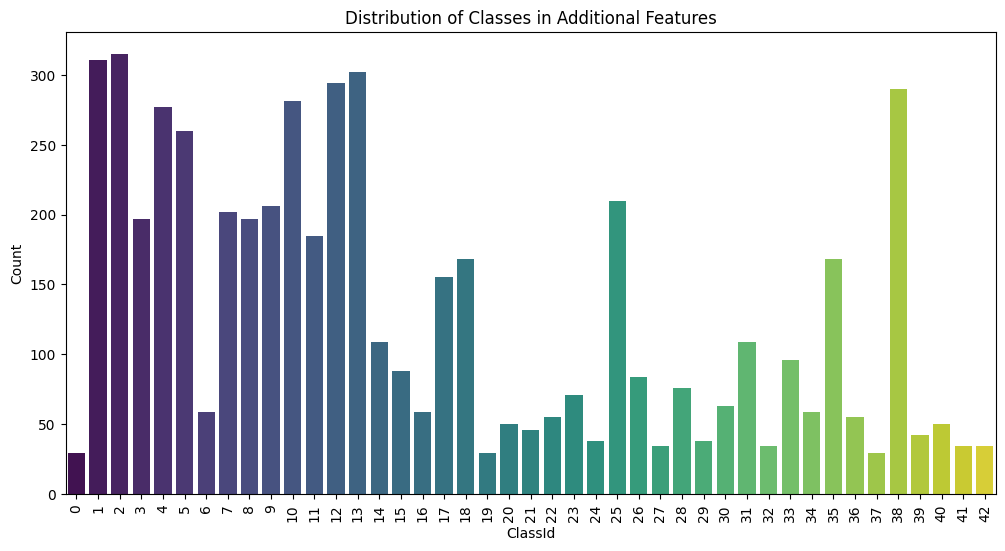

In [ ]:
# run on additional features
additional_train = pd.read_csv('train/Features/additional_features.csv')

additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler = StandardScaler()
additional_train[additional_features_columns] = scaler.fit_transform(additional_train[additional_features_columns])


training = pd.read_csv('train/train_metadata.csv')
# Merge additional features with training metadata
combined_additional = pd.merge(training, additional_train, on='image_path')
combined_additional = combined_additional.drop(columns=['id', 'image_path'])

X_additional = combined_additional.drop(columns=['ClassId']).values
Y_additional = combined_additional['ClassId'].values

# Split the data into training and validation sets
X_train_additional, X_val_additional, Y_train_additional, Y_val_additional = train_test_split(
    X_additional, Y_additional, test_size=0.2, random_state=123, stratify=Y_additional
)

# KNN on additional features
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_additional, Y_train_additional)
best_knn = grid_search.best_estimator_

# Evaluate the best KNN model on the validation set
Y_val_pred_additional = best_knn.predict(X_val_additional)
accuracy_additional = accuracy_score(Y_val_additional, Y_val_pred_additional)
print(f"Best KNN Model Accuracy on Additional Features: {accuracy_additional:.4f}", "with parameters:", grid_search.best_params_)
# Classification report for additional features
print(classification_report(Y_val_additional, Y_val_pred_additional))
# Confusion matrix for additional features
conf_matrix_additional = confusion_matrix(Y_val_additional, Y_val_pred_additional)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_additional, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Additional Features")
plt.show()

# show distribution of classes in additional features
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_additional, x='ClassId', palette='viridis')
plt.title('Distribution of Classes in Additional Features')
plt.xlabel('ClassId')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()




Best KNN Model Accuracy on HOG PCA Features: 0.7668 with parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.50      0.17      0.25         6
           1       0.74      0.63      0.68        62
           2       0.54      0.68      0.60        63
           3       0.51      0.54      0.53        39
           4       0.60      0.64      0.62        55
           5       0.65      0.62      0.63        52
           6       0.91      0.83      0.87        12
           7       0.61      0.68      0.64        40
           8       0.70      0.79      0.75        39
           9       0.81      0.95      0.88        41
          10       0.90      0.82      0.86        56
          11       0.54      0.70      0.61        37
          12       1.00      0.98      0.99        59
          13       1.00      1.00      1.00        60
          14       1.00      0.82      0.90        22
 

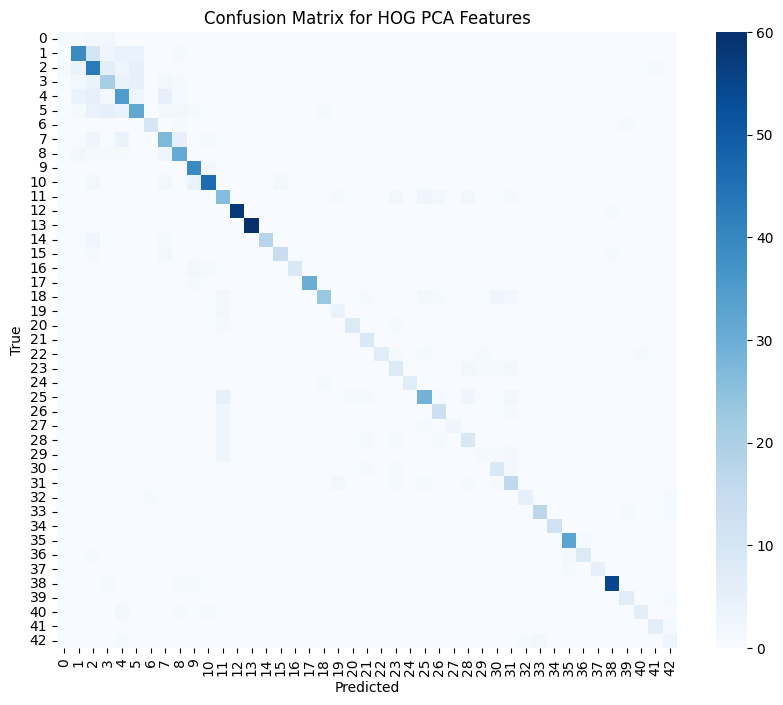

In [5]:
# run knn on hog pca features
hog_train = pd.read_csv('train/Features/hog_pca.csv')
hog_columns = [col for col in hog_train.columns if col != 'image_path']
scaler = StandardScaler()
hog_train[hog_columns] = scaler.fit_transform(hog_train[hog_columns])

training = pd.read_csv('train/train_metadata.csv')
# Merge HOG PCA features with training metadata
combined_hog = pd.merge(training, hog_train, on='image_path')

combined_hog = combined_hog.drop(columns=['id', 'image_path'])
X_hog = combined_hog.drop(columns=['ClassId']).values
Y_hog = combined_hog['ClassId'].values
# Split the data into training and validation sets
X_train_hog, X_val_hog, Y_train_hog, Y_val_hog = train_test_split(
    X_hog, Y_hog, test_size=0.2, random_state=123, stratify=Y_hog
)

# KNN on HOG PCA features
knn_hog = KNeighborsClassifier()
param_grid_hog = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_hog = GridSearchCV(knn_hog, param_grid_hog, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_hog.fit(X_train_hog, Y_train_hog)
best_knn_hog = grid_search_hog.best_estimator_
# Evaluate the best KNN model on the validation set
Y_val_pred_hog = best_knn_hog.predict(X_val_hog)
accuracy_hog = accuracy_score(Y_val_hog, Y_val_pred_hog)
print(f"Best KNN Model Accuracy on HOG PCA Features: {accuracy_hog:.4f}", "with parameters:", grid_search_hog.best_params_)
# Classification report for HOG PCA features
print(classification_report(Y_val_hog, Y_val_pred_hog))
# Confusion matrix for HOG PCA features
conf_matrix_hog = confusion_matrix(Y_val_hog, Y_val_pred_hog)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_hog, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for HOG PCA Features")
plt.show()



Test Accuracy: 0.599271402550091


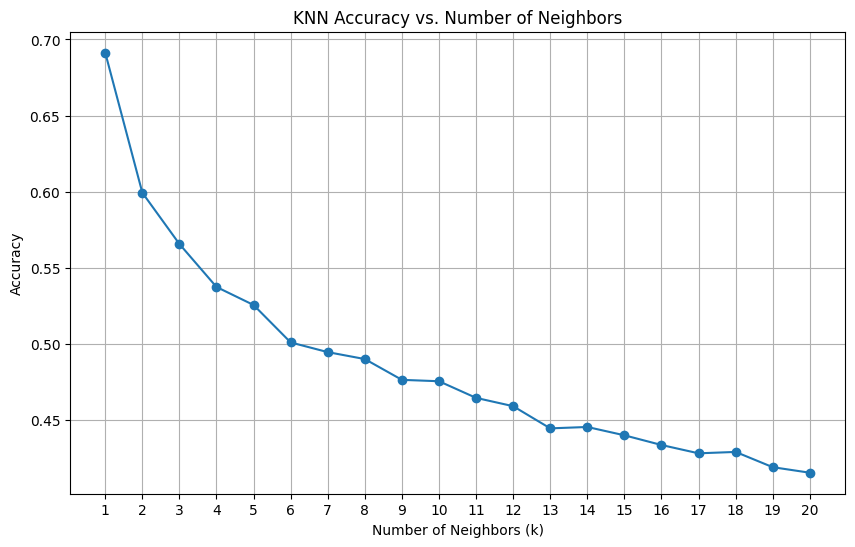

In [25]:
import pandas as pd
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Parameters
image_size = (32, 32)
image_dir = 'train/Images'
metadata_path = 'train/train_metadata.csv'

# Load metadata
metadata = pd.read_csv(metadata_path)

# Load and preprocess images
def load_images_from_metadata(metadata, image_dir, image_size=(32, 32)):
    X, y = [], []
    for _, row in metadata.iterrows():
        filename = row['image_path']
        label = row['ClassId']
        filepath = os.path.join(image_dir, filename)
        img = cv2.imread(filepath)
        if img is not None:
            try:
                img = cv2.resize(img, image_size)
                X.append(img)
                y.append(label)
            except:
                print(f"Skipping image due to resize failure: {filename}")
        else:
            print(f"Failed to load image: {filename}")
    return np.array(X).astype(np.float32), np.array(y)

# Load data
X, y = load_images_from_metadata(metadata, image_dir)
X = X / 255.0  # Normalize pixel values
X = X.reshape(X.shape[0], -1)  # Flatten for KNN

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and test KNN
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# visualise accuracy of KNN of k = 1 to k = 20
k_values = np.arange(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()
